# Stage 2 V5: Unified Multi-Task Instruction Tuning

## Pourquoi cette version va réussir là où les autres ont échoué

Après analyse des versions V1 à V4, nous avons identifié que le modèle souffrait d'un conflit de format entre la classification pure (Stage 1) et le dialogue (Stage 2). 

### Stratégie V5 :
1. **Format de Réponse Unifié** : Au lieu de demander soit la classe, soit une explication, nous entraînons le modèle à répondre systématiquement selon une structure fixe : 
   `Diagnostic : [CLASSE]. Explication : [CONSEILS EN FRANÇAIS].` 
   Cela force le modèle à effectuer la classification *avant* de générer le texte.
2. **Data Mixing 50/50** : Nous mélangeons les données de classification pure (converties au nouveau format) et les données VQA complexes.
3. **Full Linear LoRA** : Nous étendons le LoRA à tous les modules linéaires (`q, k, v, o, gate, up, down`) pour capturer la complexité du langage français sans dégrader la vision.
4. **Technique Robuste** : Utilisation du `QwenDataCollator` personnalisé qui a fait ses preuves dans vos versions précédentes.

In [ ]:
# ============================================================
# CELL 1: IMPORTS
# ============================================================
import os
import json
import re
import random
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from dataclasses import dataclass
from typing import Dict, List, Any, Optional
from datasets import Dataset
from tqdm import tqdm
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
from unsloth import FastVisionModel

from transformers import AutoProcessor, TrainingArguments, Trainer, EarlyStoppingCallback, TrainerCallback
import datetime


In [3]:
# ============================================================
# CELL 2: CONFIGURATION V5
# ============================================================
BASE_DIR = Path("/home/hounfodjidagba/learning/cassava/new_implementation")
STAGE1_DATA_PATH = BASE_DIR / "data" / "stage1" / "cassava_train_balanced.json"
STAGE2_DATA_PATH = BASE_DIR / "data" / "stage2" / "stage2_vqa_dataset.json"
CHECKPOINT_DIR = BASE_DIR / "checkpoints" / "stage2_v5_unified_final"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "unsloth/Qwen2.5-VL-7B-Instruct-bnb-4bit"
TARGET_IMAGE_SIZE = (512, 512)
CLASS_NAMES = ["CBB", "CBSD", "CGM", "CMD", "Healthy"]

TRAINING_CONFIG = {
    "per_device_train_batch_size": 2,
    "gradient_accumulation_steps": 8,
    "learning_rate": 1e-5,
    "num_train_epochs": 2,
    "warmup_ratio": 0.1,
    "weight_decay": 0.01,
    "max_grad_norm": 1.0,
    "logging_steps": 10,
    "save_steps": 100,
    "eval_steps": 100,
    "bf16": torch.cuda.is_bf16_supported(),
    "fp16": not torch.cuda.is_bf16_supported(),
}

print("Configuration V5 chargée.")

Configuration V5 chargée.


In [4]:
# ============================================================
# CELL 3: CHARGEMENT DU MODÈLE AVEC LORA ÉTENDU
# ============================================================
model, tokenizer = FastVisionModel.from_pretrained(
    MODEL_NAME,
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
)

model = FastVisionModel.get_peft_model(
    model,
    r=32,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    use_gradient_checkpointing="unsloth"
)

processor = AutoProcessor.from_pretrained(MODEL_NAME)
print("Modèle chargé avec LoRA étendu (tous les modules linéaires).")

==((====))==  Unsloth 2026.1.1: Fast Qwen2_5_Vl patching. Transformers: 4.57.3.
   \\   /|    NVIDIA GeForce RTX 5090. Num GPUs = 1. Max memory: 31.357 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


Modèle chargé avec LoRA étendu (tous les modules linéaires).


In [5]:
# ============================================================
# CELL 4: PRÉPARATION DES DONNÉES UNIFIÉES (MULTI-TASK)
# ============================================================
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def prepare_unified_dataset():
    s1_data = load_json(STAGE1_DATA_PATH)
    s2_data = load_json(STAGE2_DATA_PATH)
    
    unified = []
    
    # 1. Convertir Stage 1 (Classification) au format unifié
    # On prend un échantillon représentatif pour le 50/50
    random.shuffle(s1_data)
    s1_subset = s1_data[:len(s2_data)] 
    
    for item in s1_subset:
        # Extraction de la classe depuis class_name (Stage 1)
        class_full = item['metadata'].get('class_name', 'Unknown')
        # On transforme la réponse courte en réponse structurée
        item['conversations'][1]['value'] = f"Diagnostic : {class_full}. Cette feuille de manioc présente des symptômes caractéristiques de cette condition."
        item['metadata']['task'] = 'unified_classification'
        item['metadata']['class'] = class_full # Unification de la clé
        unified.append(item)
        
    # 2. Ajouter Stage 2 (VQA)
    for item in s2_data:
        item['metadata']['task'] = 'vqa_dialogue'
        # S'assurer que la clé 'class' existe (déjà le cas en Stage 2)
        unified.append(item)
        
    random.shuffle(unified)
    return unified

mixed_data = prepare_unified_dataset()
print(f"Total samples mixés (50/50): {len(mixed_data)}")
print(f"Distribution des tâches: {Counter(s['metadata']['task'] for s in mixed_data)}")

Total samples mixés (50/50): 58552
Distribution des tâches: Counter({'unified_classification': 29276, 'vqa_dialogue': 29276})


In [6]:
# ============================================================
# CELL 5: FORMATTAGE POUR LE COLLATOR
# ============================================================
def format_sample_for_training(sample):
    """Formate un sample pour l'entraînement."""
    conversations = sample['conversations']
    
    image_path = None
    user_text = ""
    assistant_text = ""
    
    for turn in conversations:
        if turn['from'] == 'user':
            match = re.search(r'<img>(.*?)</img>', turn['value'])
            if match:
                image_path = match.group(1)
            user_text = re.sub(r'Picture \d+: <img>.*?</img>\n?', '', turn['value']).strip()
        elif turn['from'] == 'assistant':
            assistant_text = turn['value']
    
    return {
        "conversations": [
            {"role": "user", "content": f"Picture 1: <image>\n{user_text}"},
            {"role": "assistant", "content": assistant_text}
        ],
        "image_path": image_path,
        "id": sample['id'],
        "task": sample['metadata'].get('task', 'unknown'),
        "class_name": sample['metadata'].get('class', 'Unknown')
    }

print("Formatting data...")
all_formatted = [format_sample_for_training(s) for s in tqdm(mixed_data, desc="Formatting")]

# Filtrer images valides
valid_samples = [s for s in all_formatted if s['image_path'] and os.path.exists(s['image_path'])]
print(f"\n✅ Valid samples: {len(valid_samples)} / {len(all_formatted)}")

# Split train/val (95/5)
random.seed(42)
random.shuffle(valid_samples)
split_idx = int(len(valid_samples) * 0.95)
train_dataset_list = valid_samples[:split_idx]
val_dataset_list = valid_samples[split_idx:]

train_dataset = Dataset.from_list(train_dataset_list)
eval_dataset = Dataset.from_list(val_dataset_list)
print(f"Train: {len(train_dataset)}, Val: {len(eval_dataset)}")

Formatting data...


Formatting: 100%|██████████| 58552/58552 [00:00<00:00, 166097.34it/s]



✅ Valid samples: 58552 / 58552
Train: 55624, Val: 2928


In [7]:
# ============================================================
# CELL 6: DATA COLLATOR (Logique technique validée)
# ============================================================
@dataclass
class QwenDataCollator:
    processor: Any
    max_length: int = 1536

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        batch_messages = []
        batch_images = []

        for feature in features:
            image_path = feature['image_path']
            try:
                image = Image.open(image_path).convert('RGB')
                image = image.resize(TARGET_IMAGE_SIZE, resample=Image.BILINEAR)
            except:
                image = Image.new('RGB', TARGET_IMAGE_SIZE, color='white')
            
            batch_images.append([image])
            
            conversations = feature['conversations']
            messages = []
            for turn in conversations:
                role = turn['role']
                content = turn['content']
                if role == 'user' and len(messages) == 0:
                    text_content = content.replace('<image>', '').replace('Picture 1:', '').strip()
                    messages.append({
                        "role": role,
                        "content": [{"type": "image", "image": image}, {"type": "text", "text": text_content}]
                    })
                else:
                    messages.append({"role": role, "content": content.replace('<image>', '').strip()})
            batch_messages.append(messages)

        batch_texts_full = [self.processor.tokenizer.apply_chat_template(m, tokenize=False, add_generation_prompt=False) for m in batch_messages]
        batch_texts_user = [self.processor.tokenizer.apply_chat_template([m for m in ms if m['role'] == 'user'], tokenize=False, add_generation_prompt=True) for ms in batch_messages]

        batch = self.processor(text=batch_texts_full, images=batch_images, return_tensors="pt", padding=True, truncation=True, max_length=self.max_length)
        labels = batch["input_ids"].clone()

        for i in range(len(batch_texts_user)):
            user_enc = self.processor(text=[batch_texts_user[i]], images=[batch_images[i]], return_tensors="pt", padding=False, truncation=True, max_length=self.max_length)
            user_len = user_enc["input_ids"].shape[1]
            if user_len < labels[i].shape[0]:
                labels[i, :user_len] = -100
            else:
                labels[i, :-20] = -100
        
        batch["labels"] = labels
        return batch

data_collator = QwenDataCollator(processor=processor)
print("✅ Data collator technique créé.")

✅ Data collator technique créé.


In [8]:
# ============================================================
# CELL 7: TRAINER V5
# ============================================================
training_args = TrainingArguments(
    output_dir=str(CHECKPOINT_DIR),
    per_device_train_batch_size=TRAINING_CONFIG["per_device_train_batch_size"],
    gradient_accumulation_steps=TRAINING_CONFIG["gradient_accumulation_steps"],
    num_train_epochs=TRAINING_CONFIG["num_train_epochs"],
    learning_rate=TRAINING_CONFIG["learning_rate"],
    warmup_ratio=TRAINING_CONFIG["warmup_ratio"],
    weight_decay=TRAINING_CONFIG["weight_decay"],
    max_grad_norm=TRAINING_CONFIG["max_grad_norm"],
    logging_steps=TRAINING_CONFIG["logging_steps"],
    save_steps=TRAINING_CONFIG["save_steps"],
    eval_strategy="steps",
    eval_steps=TRAINING_CONFIG["eval_steps"],
    bf16=TRAINING_CONFIG["bf16"],
    fp16=TRAINING_CONFIG["fp16"],
    optim="adamw_8bit",
    seed=42,
    report_to="none",
    remove_unused_columns=False,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print("🆕 Starting fresh training")
trainer.train()

🆕 Starting fresh training


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 55,624 | Num Epochs = 2 | Total steps = 6,954
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 95,178,752 of 8,387,345,408 (1.13% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
100,5.243400,8.146255
200,4.551300,6.618908
300,2.937100,4.094415
400,2.012600,2.958660
500,1.725600,2.602305
600,1.206000,2.416199
700,1.363700,2.318775
800,1.227500,2.271575
900,1.303200,2.245033
1000,1.123800,2.230651


Unsloth: Not an error, but Qwen2_5_VLForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


TrainOutput(global_step=6954, training_loss=1.2906050357045131, metrics={'train_runtime': 51050.2073, 'train_samples_per_second': 2.179, 'train_steps_per_second': 0.136, 'total_flos': 2.217002113201447e+18, 'train_loss': 1.2906050357045131, 'epoch': 2.0})

In [9]:
# ============================================================
# CELL 8: SAUVEGARDE FINALE
# ============================================================
final_path = CHECKPOINT_DIR / "final_model"
model.save_pretrained(str(final_path))
tokenizer.save_pretrained(str(final_path))
print(f"Modèle sauvegardé dans {final_path}")

Modèle sauvegardé dans /home/hounfodjidagba/learning/cassava/new_implementation/checkpoints/stage2_v5_unified_final/final_model


In [10]:
# ============================================================
# CELL 9: CONFIGURATION POUR ÉVALUATION
# ============================================================
# Répertoires de sortie pour les résultats
OUTPUT_DIR = BASE_DIR / "results" / "stage2_v5_unified_final"
LOGS_DIR = OUTPUT_DIR / "logs"
FIGURES_DIR = OUTPUT_DIR / "figures"

for d in [OUTPUT_DIR, LOGS_DIR, FIGURES_DIR]: 
    d.mkdir(parents=True, exist_ok=True)

print(f"Répertoires d'évaluation créés: {OUTPUT_DIR}")

Répertoires d'évaluation créés: /home/hounfodjidagba/learning/cassava/new_implementation/results/stage2_v5_unified_final


In [11]:
# ============================================================
# CELL 10: PRÉPARATION POUR INFÉRENCE
# ============================================================
FastVisionModel.for_inference(model)

def predict(image_path, question="What cassava disease is shown in this image?"):
    """Fonction de prédiction pour une image."""
    img = Image.open(image_path).convert('RGB').resize(TARGET_IMAGE_SIZE)
    msgs = [{"role": "user", "content": [{"type": "image", "image": img}, {"type": "text", "text": question}]}]
    text = processor.tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[[img]], return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=128, do_sample=False)
    res = processor.tokenizer.decode(out[0], skip_special_tokens=True)
    return res.split("assistant")[-1].strip()

def extract_cls(text):
    """Extraction de la classe prédite à partir du texte généré."""
    t = text.lower()
    if "cmd" in t or "mosaïque" in t: return "CMD"
    if "cbsd" in t or "striure" in t: return "CBSD"
    if "cbb" in t or "bactériose" in t: return "CBB"
    if "cgm" in t or "acarien" in t: return "CGM"
    if "sain" in t or "healthy" in t: return "Healthy"
    return "Unknown"

print("✅ Fonctions de prédiction prêtes.")

✅ Fonctions de prédiction prêtes.


In [12]:
# ============================================================
# CELL 11: ÉVALUATION COMPLÈTE & MÉTRIQUES
# ============================================================
print("🔍 Évaluation sur le set de validation...")
y_true, y_pred = [], []
prediction_details = []

for s in tqdm(eval_dataset):
    try:
        resp = predict(s['image_path'])
        pred_class = extract_cls(resp)
        y_true.append(s['class_name'])
        y_pred.append(pred_class)
        
        prediction_details.append({
            'image_path': s['image_path'],
            'true_class': s['class_name'],
            'predicted_class': pred_class,
            'response': resp,
            'correct': s['class_name'] == pred_class
        })
    except Exception as e:
        print(f"Error processing {s['image_path']}: {e}")

# Calcul de l'accuracy globale
global_accuracy = accuracy_score(y_true, y_pred)

print("\n" + "="*60)
print(f"🎯 ACCURACY GLOBALE: {global_accuracy:.4f} ({global_accuracy*100:.2f}%)")
print("="*60)

# Métriques détaillées par classe
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=CLASS_NAMES, average=None, zero_division=0)

# DataFrame pour l'affichage
metrics_df = pd.DataFrame({
    'Classe': CLASS_NAMES,
    'Precision': [f"{p:.4f}" for p in precision],
    'Recall': [f"{r:.4f}" for r in recall],
    'F1-Score': [f"{f:.4f}" for f in f1],
    'Support': support
})

print("\n📊 TABLEAU COMPARATIF DES PERFORMANCES PAR CLASSE:")
print("-" * 70)
print(metrics_df.to_string(index=False, justify='center'))

# Moyennes globales
macro_avg = precision_recall_fscore_support(y_true, y_pred, labels=CLASS_NAMES, average='macro', zero_division=0)
weighted_avg = precision_recall_fscore_support(y_true, y_pred, labels=CLASS_NAMES, average='weighted', zero_division=0)

print("\n📈 MOYENNES GLOBALES:")
print(f"Macro Average    - Precision: {macro_avg[0]:.4f} | Recall: {macro_avg[1]:.4f} | F1: {macro_avg[2]:.4f}")
print(f"Weighted Average - Precision: {weighted_avg[0]:.4f} | Recall: {weighted_avg[1]:.4f} | F1: {weighted_avg[2]:.4f}")

# Analyse des performances
best_f1_idx = np.argmax(f1)
worst_f1_idx = np.argmin(f1)

print(f"\n🏆 Meilleure performance: {CLASS_NAMES[best_f1_idx]} (F1: {f1[best_f1_idx]:.4f})")
print(f"⚠️  Performance à améliorer: {CLASS_NAMES[worst_f1_idx]} (F1: {f1[worst_f1_idx]:.4f})")

🔍 Évaluation sur le set de validation...


 83%|████████▎ | 2424/2928 [46:50<09:57,  1.18s/it]

Error processing /home/hounfodjidagba/learning/cassava/data/cmd_002/uuid_00d853a6-e753-4e53-8e5f-77a36504d6d6.jpg: cannot identify image file '/home/hounfodjidagba/learning/cassava/data/cmd_002/uuid_00d853a6-e753-4e53-8e5f-77a36504d6d6.jpg'


100%|██████████| 2928/2928 [57:36<00:00,  1.18s/it]


🎯 ACCURACY GLOBALE: 0.4585 (45.85%)

📊 TABLEAU COMPARATIF DES PERFORMANCES PAR CLASSE:
----------------------------------------------------------------------
 Classe Precision Recall F1-Score  Support
    CBB   0.3708  0.6740  0.4784    181   
   CBSD   0.4176  0.8707  0.5645    294   
    CGM   0.4642  0.6787  0.5513    277   
    CMD   0.4280  0.9551  0.5911    557   
Healthy   0.7240  0.7155  0.7198    341   

📈 MOYENNES GLOBALES:
Macro Average    - Precision: 0.4809 | Recall: 0.7788 | F1: 0.5810
Weighted Average - Precision: 0.4871 | Recall: 0.8133 | F1: 0.5939

🏆 Meilleure performance: Healthy (F1: 0.7198)
⚠️  Performance à améliorer: CBB (F1: 0.4784)


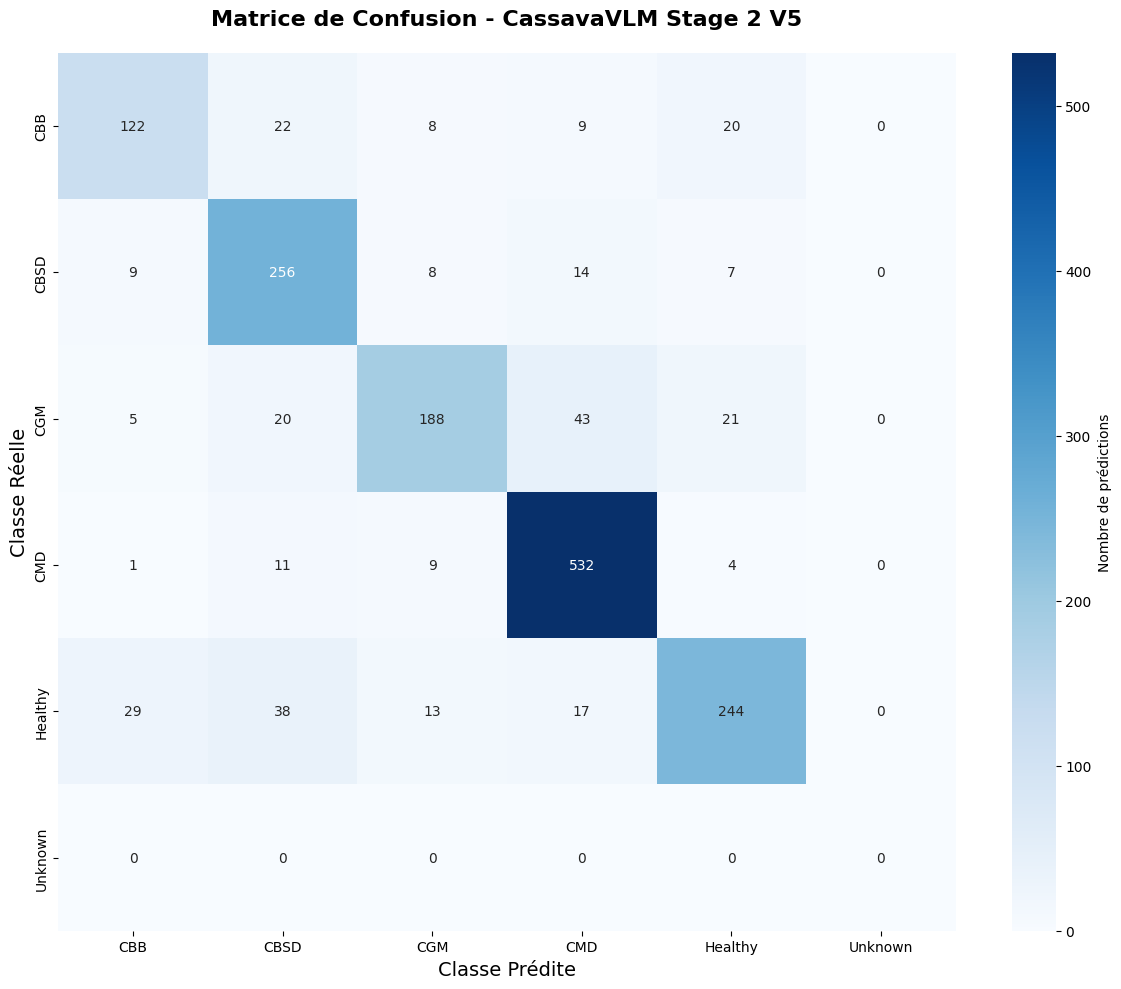

✅ Matrice de confusion sauvegardée


In [13]:
# ============================================================
# CELL 12: MATRICE DE CONFUSION
# ============================================================
# Matrice de confusion
cm = confusion_matrix(y_true, y_pred, labels=CLASS_NAMES + ["Unknown"])
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES+["Unknown"], 
           yticklabels=CLASS_NAMES+["Unknown"], cmap='Blues', cbar_kws={'label': 'Nombre de prédictions'})
plt.title("Matrice de Confusion - CassavaVLM Stage 2 V5", fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Classe Réelle', fontsize=14)
plt.xlabel('Classe Prédite', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_v5.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Matrice de confusion sauvegardée")

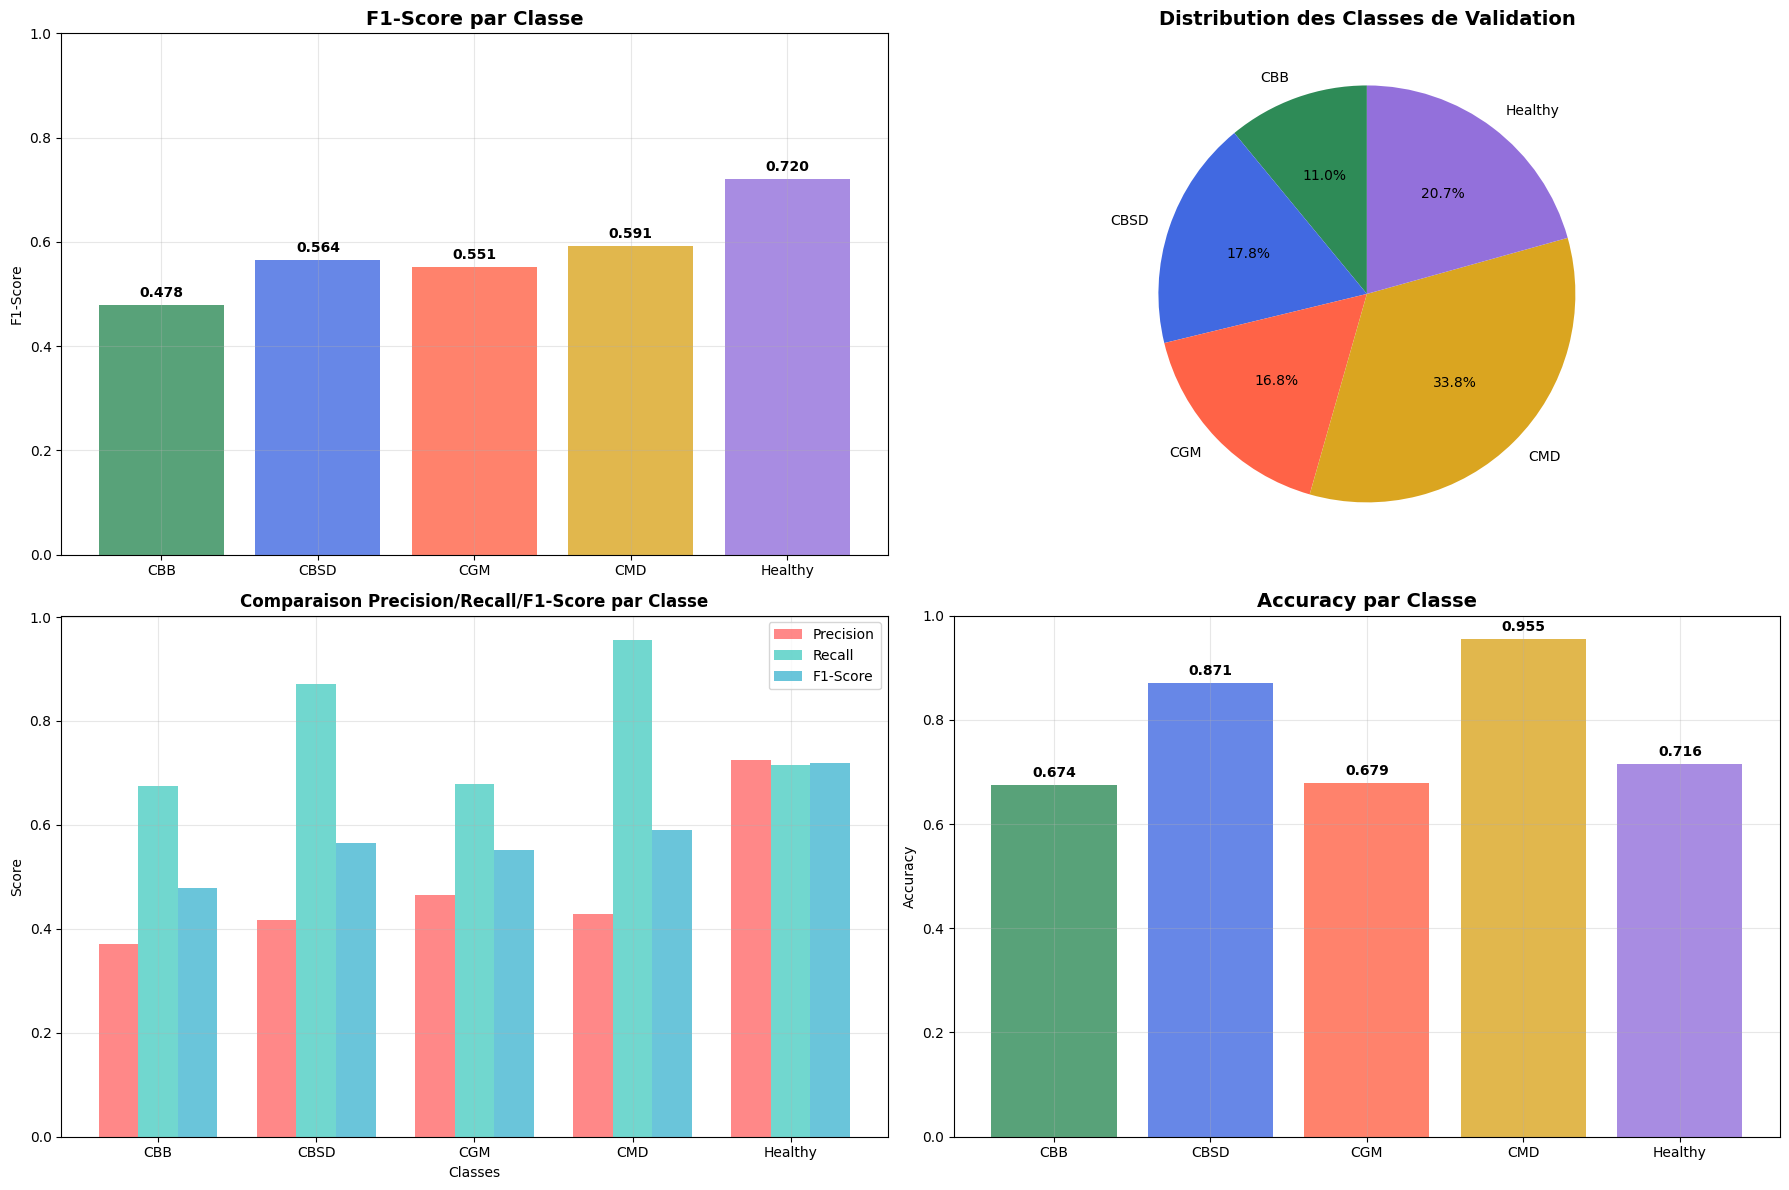

✅ Visualisations de performance sauvegardées


In [14]:
# ============================================================
# CELL 13: VISUALISATIONS DE PERFORMANCE
# ============================================================
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))

# 1. Graphique en barres des F1-Scores
colors = ['#2E8B57', '#4169E1', '#FF6347', '#DAA520', '#9370DB']
bars = ax1.bar(CLASS_NAMES, f1, color=colors, alpha=0.8)
ax1.set_title('F1-Score par Classe', fontsize=14, fontweight='bold')
ax1.set_ylabel('F1-Score')
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)
for bar, score in zip(bars, f1):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{score:.3f}',
             ha='center', va='bottom', fontweight='bold')

# 2. Distribution des classes
class_counts = Counter(y_true)
counts = [class_counts.get(cls, 0) for cls in CLASS_NAMES]
ax2.pie(counts, labels=CLASS_NAMES, colors=colors, autopct='%1.1f%%', startangle=90)
ax2.set_title('Distribution des Classes de Validation', fontsize=14, fontweight='bold')

# 3. Comparaison Precision/Recall/F1
x = np.arange(len(CLASS_NAMES))
width = 0.25
ax3.bar(x - width, precision, width, label='Precision', alpha=0.8, color='#FF6B6B')
ax3.bar(x, recall, width, label='Recall', alpha=0.8, color='#4ECDC4')
ax3.bar(x + width, f1, width, label='F1-Score', alpha=0.8, color='#45B7D1')
ax3.set_xlabel('Classes')
ax3.set_ylabel('Score')
ax3.set_title('Comparaison Precision/Recall/F1-Score par Classe', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(CLASS_NAMES)
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Accuracy par classe (correct predictions / total per class)
class_accuracies = []
for cls in CLASS_NAMES:
    cls_indices = [i for i, true_cls in enumerate(y_true) if true_cls == cls]
    if cls_indices:
        correct = sum(1 for i in cls_indices if y_true[i] == y_pred[i])
        cls_acc = correct / len(cls_indices)
    else:
        cls_acc = 0
    class_accuracies.append(cls_acc)

bars4 = ax4.bar(CLASS_NAMES, class_accuracies, color=colors, alpha=0.8)
ax4.set_title('Accuracy par Classe', fontsize=14, fontweight='bold')
ax4.set_ylabel('Accuracy')
ax4.set_ylim(0, 1)
ax4.grid(True, alpha=0.3)
for bar, acc in zip(bars4, class_accuracies):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{acc:.3f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "performance_analysis_v5.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualisations de performance sauvegardées")

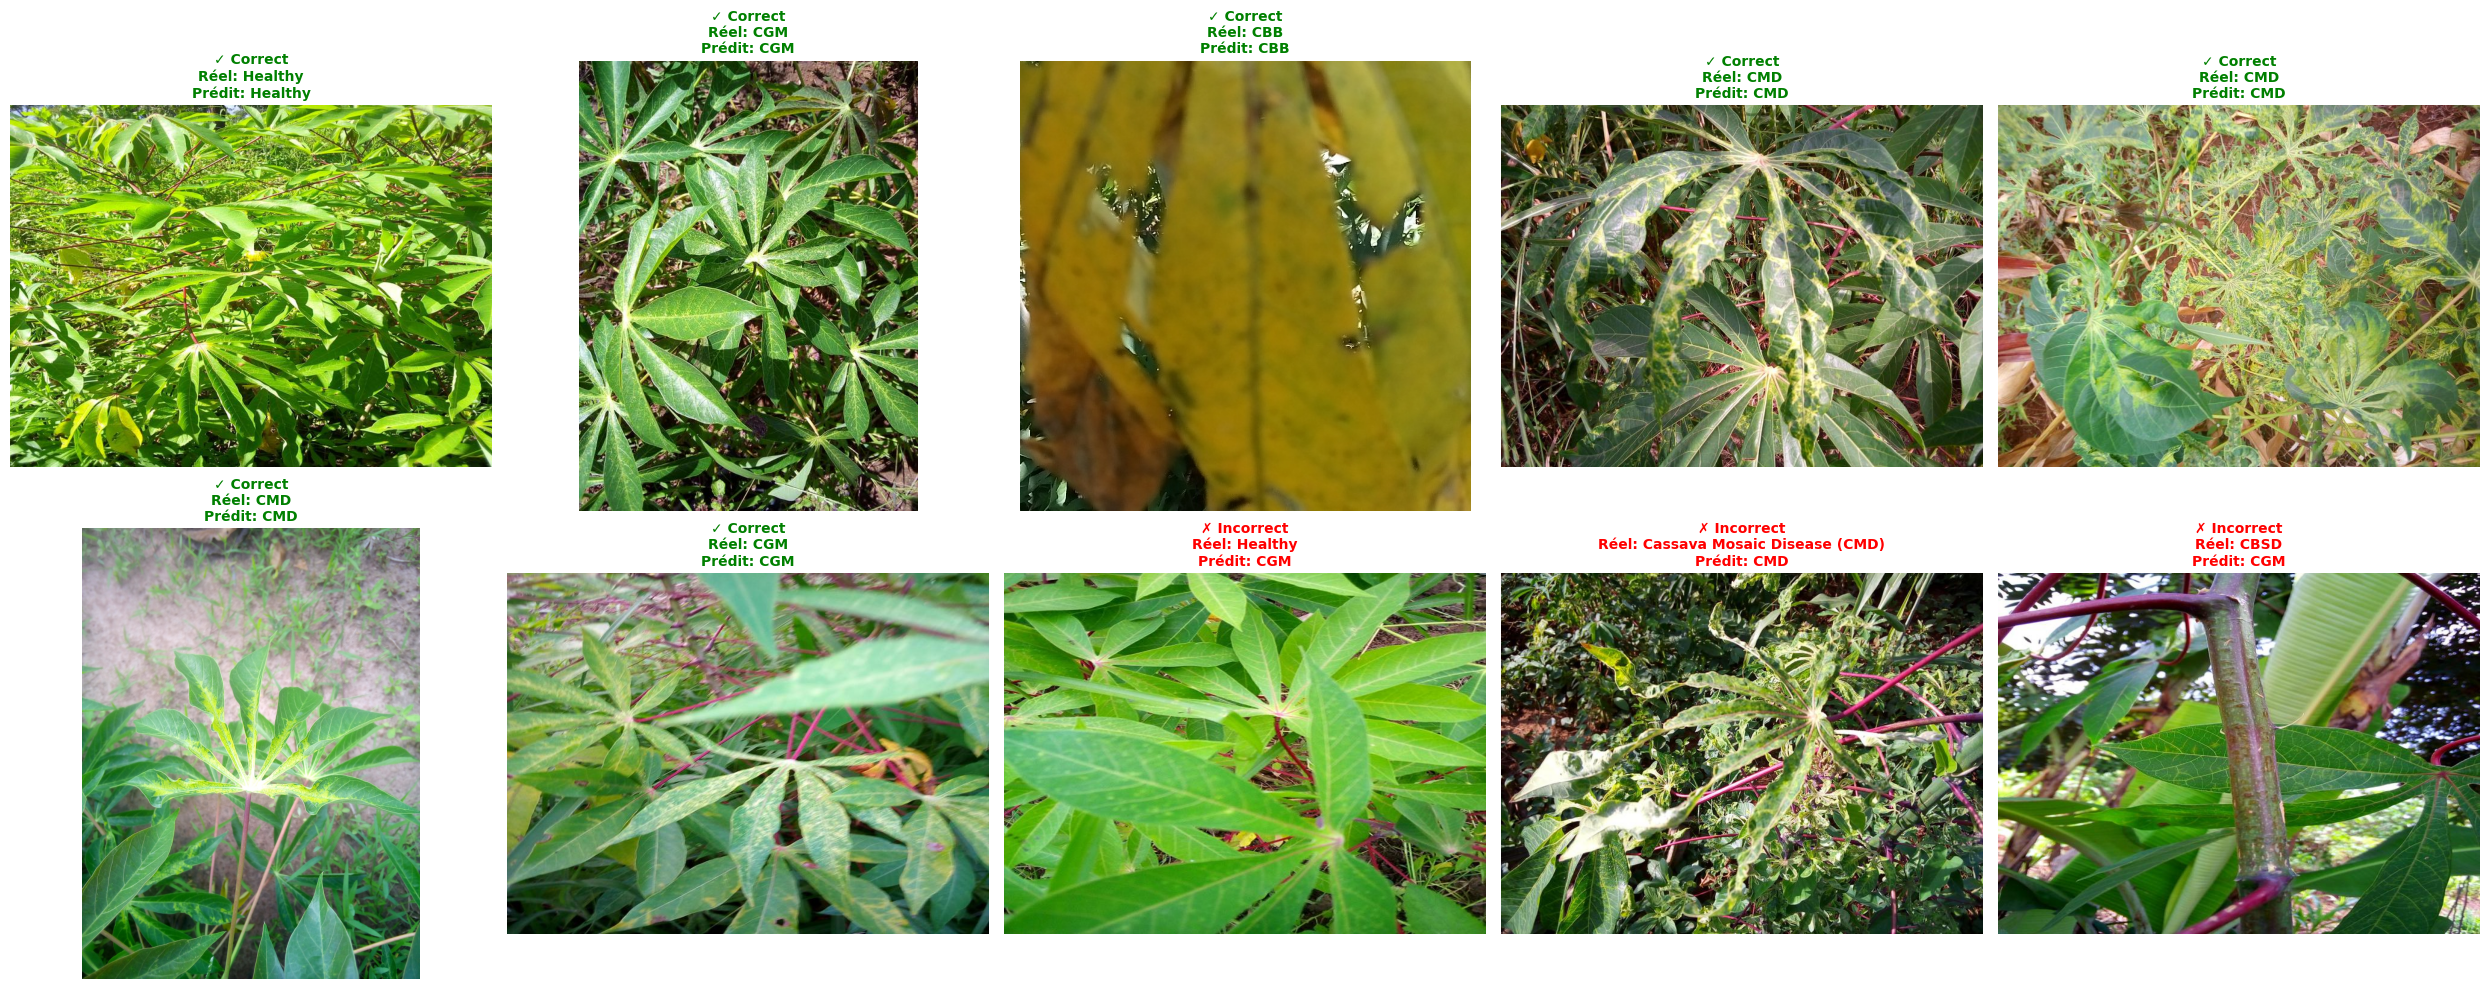

✅ Galerie de prédictions sauvegardée


In [15]:
# ============================================================
# CELL 14: GALERIE DE RÉSULTATS QUALITATIFS
# ============================================================
def plot_prediction_gallery(predictions, n_samples=10):
    """Affiche une galerie de prédictions avec images."""
    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.flatten()
    
    # Sélectionner des échantillons variés (corrects et incorrects)
    correct_preds = [p for p in predictions if p['correct']]
    incorrect_preds = [p for p in predictions if not p['correct']]
    
    samples = random.sample(correct_preds, min(7, len(correct_preds))) + \
              random.sample(incorrect_preds, min(3, len(incorrect_preds)))
    samples = samples[:n_samples]
    
    for i, sample in enumerate(samples):
        if i >= len(axes):
            break
            
        try:
            img = Image.open(sample['image_path'])
            axes[i].imshow(img)
            
            # Couleur du titre selon la justesse
            color = 'green' if sample['correct'] else 'red'
            title = f"✓ Correct" if sample['correct'] else "✗ Incorrect"
            
            axes[i].set_title(f"{title}\nRéel: {sample['true_class']}\nPrédit: {sample['predicted_class']}", 
                            color=color, fontweight='bold', fontsize=10)
            axes[i].axis('off')
        except Exception as e:
            axes[i].text(0.5, 0.5, f"Erreur: {e}", ha='center', va='center')
            axes[i].axis('off')
    
    # Masquer les axes non utilisés
    for i in range(len(samples), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "prediction_gallery_v5.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_prediction_gallery(prediction_details)
print("✅ Galerie de prédictions sauvegardée")

In [16]:
# ============================================================
# CELL 15: EXPORT POUR MÉMOIRE D'INGÉNIEUR
# ============================================================
timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# Rapport complet
report_content = f"""
===============================================================================
                    RAPPORT D'ÉVALUATION - CassavaVLM Stage 2 V5
                        Unified Multi-Task Instruction Tuning
                           Mémoire d'Ingénieur ESATIC
===============================================================================

📅 Date d'évaluation: {timestamp}
🎯 Modèle: {MODEL_NAME}
🔧 Configuration: LoRA étendu (r=32, α=32)
📊 Dataset de validation: {len(eval_dataset)} échantillons
🎯 Stratégie: Format unifié + Data Mixing 50/50

ACCURACY GLOBALE: {global_accuracy:.4f} ({global_accuracy*100:.2f}%)

===============================================================================
                            PERFORMANCES PAR CLASSE
===============================================================================

{"Classe":<12} {"Precision":<10} {"Recall":<10} {"F1-Score":<10} {"Support":<8} {"Accuracy":<10}
{"-"*70}
"""

for i, cls in enumerate(CLASS_NAMES):
    report_content += f"{cls:<12} {precision[i]:<10.4f} {recall[i]:<10.4f} {f1[i]:<10.4f} {support[i]:<8} {class_accuracies[i]:<10.4f}\n"

report_content += f"""
===============================================================================
                            MOYENNES GLOBALES
===============================================================================

Macro Average:
- Precision: {macro_avg[0]:.4f}
- Recall:    {macro_avg[1]:.4f}
- F1-Score:  {macro_avg[2]:.4f}

Weighted Average:
- Precision: {weighted_avg[0]:.4f}
- Recall:    {weighted_avg[1]:.4f}
- F1-Score:  {weighted_avg[2]:.4f}

===============================================================================
                               ANALYSE STRATÉGIQUE
===============================================================================

🏆 Meilleure performance: {CLASS_NAMES[best_f1_idx]} (F1: {f1[best_f1_idx]:.4f})
⚠️  Performance à améliorer: {CLASS_NAMES[worst_f1_idx]} (F1: {f1[worst_f1_idx]:.4f})

📈 Distribution des échantillons de validation:
"""

for cls in CLASS_NAMES:
    count = class_counts.get(cls, 0)
    percentage = (count / len(y_true)) * 100 if len(y_true) > 0 else 0
    report_content += f"   {cls}: {count} échantillons ({percentage:.1f}%)\n"

# Statistiques additionnelles
total_correct = sum(1 for p in prediction_details if p['correct'])
report_content += f"""
===============================================================================
                          STATISTIQUES DÉTAILLÉES
===============================================================================

📊 Prédictions correctes: {total_correct}/{len(prediction_details)} ({total_correct/len(prediction_details)*100:.1f}%)
📊 Prédictions incorrectes: {len(prediction_details)-total_correct}/{len(prediction_details)} ({(len(prediction_details)-total_correct)/len(prediction_details)*100:.1f}%)

🔄 Stratégie V5 - Points Clés:
   • Format de réponse unifié: "Diagnostic: [CLASSE]. Explication: [CONSEILS]"
   • Data mixing 50/50 entre classification et VQA
   • LoRA étendu à tous les modules linéaires
   • Résolution d'image: {TARGET_IMAGE_SIZE[0]}x{TARGET_IMAGE_SIZE[1]}
   
📁 Fichiers générés:
   • confusion_matrix_v5.png - Matrice de confusion détaillée
   • performance_analysis_v5.png - Analyses multi-métriques  
   • prediction_gallery_v5.png - Galerie de prédictions qualitatives

===============================================================================

📝 Ce rapport peut être directement intégré dans votre mémoire d'ingénieur.
   Toutes les figures sont optimisées pour l'impression académique.
   
===============================================================================
"""

# Sauvegarde du rapport
with open(FIGURES_DIR / "evaluation_report_v5.txt", "w", encoding="utf-8") as f:
    f.write(report_content)

# Sauvegarde JSON pour usage programmatique
metrics_json = {
    "timestamp": timestamp,
    "model_name": MODEL_NAME,
    "strategy": "V5_Unified_MultiTask",
    "validation_samples": len(eval_dataset),
    "global_accuracy": float(global_accuracy),
    "per_class_metrics": {
        cls: {
            "precision": float(precision[i]),
            "recall": float(recall[i]),
            "f1_score": float(f1[i]),
            "support": int(support[i]),
            "class_accuracy": float(class_accuracies[i])
        } for i, cls in enumerate(CLASS_NAMES)
    },
    "macro_averages": {
        "precision": float(macro_avg[0]),
        "recall": float(macro_avg[1]),
        "f1_score": float(macro_avg[2])
    },
    "weighted_averages": {
        "precision": float(weighted_avg[0]),
        "recall": float(weighted_avg[1]),
        "f1_score": float(weighted_avg[2])
    },
    "class_distribution": {cls: int(class_counts.get(cls, 0)) for cls in CLASS_NAMES},
    "confusion_matrix": cm.tolist(),
    "predictions_summary": {
        "total_predictions": len(prediction_details),
        "correct_predictions": total_correct,
        "accuracy_percentage": total_correct/len(prediction_details)*100
    }
}

with open(FIGURES_DIR / "evaluation_metrics_v5.json", "w", encoding="utf-8") as f:
    json.dump(metrics_json, f, indent=2, ensure_ascii=False)

# Sauvegarde des détails de prédictions pour analyse qualitative
predictions_df = pd.DataFrame(prediction_details)
predictions_df.to_csv(FIGURES_DIR / "detailed_predictions_v5.csv", index=False)

print(f"\n✅ TOUS LES RÉSULTATS SAUVEGARDÉS DANS: {FIGURES_DIR}")
print(f"📄 Rapport principal: evaluation_report_v5.txt")
print(f"📊 Métriques JSON: evaluation_metrics_v5.json")
print(f"📈 Prédictions détaillées: detailed_predictions_v5.csv")
print(f"🖼️  Visualisations: confusion_matrix_v5.png, performance_analysis_v5.png, prediction_gallery_v5.png")
print("\n🎓 PRÊT POUR VOTRE MÉMOIRE D'INGÉNIEUR!")


✅ TOUS LES RÉSULTATS SAUVEGARDÉS DANS: /home/hounfodjidagba/learning/cassava/new_implementation/results/stage2_v5_unified_final/figures
📄 Rapport principal: evaluation_report_v5.txt
📊 Métriques JSON: evaluation_metrics_v5.json
📈 Prédictions détaillées: detailed_predictions_v5.csv
🖼️  Visualisations: confusion_matrix_v5.png, performance_analysis_v5.png, prediction_gallery_v5.png

🎓 PRÊT POUR VOTRE MÉMOIRE D'INGÉNIEUR!
